In [1]:
import pandas as pd
df = pd.read_csv("user_personalized_features.csv")

In [2]:
print("数据形状(行,列):",df.shape)
print()
print("列名:",df.columns.tolist())
print()
print("每列类型:")
print(df.dtypes)

数据形状(行,列): (1000, 15)

列名: ['Unnamed: 0', 'User_ID', 'Age', 'Gender', 'Location', 'Income', 'Interests', 'Last_Login_Days_Ago', 'Purchase_Frequency', 'Average_Order_Value', 'Total_Spending', 'Product_Category_Preference', 'Time_Spent_on_Site_Minutes', 'Pages_Viewed', 'Newsletter_Subscription']

每列类型:
Unnamed: 0                     int64
User_ID                          str
Age                            int64
Gender                           str
Location                         str
Income                         int64
Interests                        str
Last_Login_Days_Ago            int64
Purchase_Frequency             int64
Average_Order_Value            int64
Total_Spending                 int64
Product_Category_Preference      str
Time_Spent_on_Site_Minutes     int64
Pages_Viewed                   int64
Newsletter_Subscription         bool
dtype: object


In [3]:
print("前5行:")
print(df.head())
print()
print("后3行:")
print(df.tail(3))
print()
print("数值统计:")
print(df.describe())
print()
print("每列缺失值:")
print(df.isnull().sum())

前5行:
   Unnamed: 0 User_ID  Age  Gender  Location  Income   Interests  \
0           0      #1   56    Male  Suburban   38037      Sports   
1           1      #2   46  Female     Rural  103986  Technology   
2           2      #3   32  Female  Suburban  101942      Sports   
3           3      #4   60  Female  Suburban   71612     Fashion   
4           4      #5   25    Male  Suburban   49725      Travel   

   Last_Login_Days_Ago  Purchase_Frequency  Average_Order_Value  \
0                    5                   7                   18   
1                   15                   7                  118   
2                   28                   1                  146   
3                   18                   3                  163   
4                    2                   5                  141   

   Total_Spending Product_Category_Preference  Time_Spent_on_Site_Minutes  \
0            2546                       Books                         584   
1             320            

In [4]:
df = df.drop(columns=["Unnamed: 0"])
print("删除后形状:", df.shape)
print()

print("重复用户数:",df["User_ID"].duplicated().sum())
print()
print("完全重复的行数:",df.duplicated().sum())

删除后形状: (1000, 14)

重复用户数: 0

完全重复的行数: 0


In [5]:
num_cols = ["Age", "Income", "Last_Login_Days_Ago", "Purchase_Frequency",
            "Average_Order_Value", "Total_Spending",
            "Time_Spent_on_Site_Minutes", "Pages_Viewed"]
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col]<lower) | (df[col]>upper)).sum()
    print(f"{col}:正常范围[{lower:0f},{upper:0f}],异常值{n_outliers}个")

Age:正常范围[-5.500000,86.500000],异常值0个
Income:正常范围[-47253.000000,208663.000000],异常值0个
Last_Login_Days_Ago:正常范围[-14.500000,45.500000],异常值0个
Purchase_Frequency:正常范围[-5.500000,14.500000],异常值0个
Average_Order_Value:正常范围[-80.000000,288.000000],异常值0个
Total_Spending:正常范围[-2573.875000,7681.125000],异常值0个
Time_Spent_on_Site_Minutes:正常范围[-313.875000,907.125000],异常值0个
Pages_Viewed:正常范围[-24.000000,72.000000],异常值0个


In [6]:
df.to_csv("data_clean.csv",index=False)
print("已保存 data_clean.csv")
print()
print("最终数据形状:",df.shape)
print("最终列名:",df.columns.tolist())

已保存 data_clean.csv

最终数据形状: (1000, 14)
最终列名: ['User_ID', 'Age', 'Gender', 'Location', 'Income', 'Interests', 'Last_Login_Days_Ago', 'Purchase_Frequency', 'Average_Order_Value', 'Total_Spending', 'Product_Category_Preference', 'Time_Spent_on_Site_Minutes', 'Pages_Viewed', 'Newsletter_Subscription']


In [7]:
print("=== 性别分布 ===");print(df["Gender"].value_counts());print()
print("=== 地区分布 ===");print(df["Location"].value_counts());print()
print("=== 兴趣分布 ===");print(df["Interests"].value_counts());print()
print("=== 偏好分布 ===");print(df["Product_Category_Preference"].value_counts());print()
print("=== 订阅分布 ===");print(df["Newsletter_Subscription"].value_counts());print()      

=== 性别分布 ===
Gender
Male      526
Female    474
Name: count, dtype: int64

=== 地区分布 ===
Location
Suburban    349
Urban       344
Rural       307
Name: count, dtype: int64

=== 兴趣分布 ===
Interests
Sports        213
Fashion       209
Travel        196
Food          196
Technology    186
Name: count, dtype: int64

=== 偏好分布 ===
Product_Category_Preference
Apparel            218
Electronics        209
Books              198
Home & Kitchen     189
Health & Beauty    186
Name: count, dtype: int64

=== 订阅分布 ===
Newsletter_Subscription
True     507
False    493
Name: count, dtype: int64



In [8]:
# ============ 第4步：相关性分析 ============
# 选出要分析的数值列
num_cols = ["Age", "Income", "Last_Login_Days_Ago", "Purchase_Frequency",
            "Average_Order_Value", "Total_Spending",
            "Time_Spent_on_Site_Minutes", "Pages_Viewed"]

# 计算相关系数矩阵
corr = df[num_cols].corr()
print("相关系数矩阵:")
print(corr.round(2))

相关系数矩阵:
                             Age  Income  Last_Login_Days_Ago  \
Age                         1.00    0.01                 0.05   
Income                      0.01    1.00                -0.02   
Last_Login_Days_Ago         0.05   -0.02                 1.00   
Purchase_Frequency         -0.03    0.01                 0.03   
Average_Order_Value         0.02   -0.01                 0.01   
Total_Spending              0.02   -0.08                 0.05   
Time_Spent_on_Site_Minutes  0.00   -0.02                -0.01   
Pages_Viewed                0.02   -0.05                -0.04   

                            Purchase_Frequency  Average_Order_Value  \
Age                                      -0.03                 0.02   
Income                                    0.01                -0.01   
Last_Login_Days_Ago                       0.03                 0.01   
Purchase_Frequency                        1.00                -0.03   
Average_Order_Value                      -0.03     

In [9]:
# 重点：停留时间 与 购买频率 的相关系数
r1 = df["Time_Spent_on_Site_Minutes"].corr(df["Purchase_Frequency"])
print(f"停留时间 ~ 购买频率 相关系数: {r1:.4f}")

# 重点：浏览页数 与 购买频率 的相关系数
r2 = df["Pages_Viewed"].corr(df["Purchase_Frequency"])
print(f"浏览页数 ~ 购买频率 相关系数: {r2:.4f}")

停留时间 ~ 购买频率 相关系数: -0.0282
浏览页数 ~ 购买频率 相关系数: 0.0257


In [10]:
# 把停留时间分成4组，对比各组的平均购买频率
df["time_group"] = pd.qcut(df["Time_Spent_on_Site_Minutes"], 4, 
                           labels=["最短25%", "较短", "较长", "最长25%"])
print("停留时间分组 vs 平均购买频率:")
print(df.groupby("time_group", observed=True)["Purchase_Frequency"].mean().round(2))

停留时间分组 vs 平均购买频率:
time_group
最短25%    4.72
较短       4.62
较长       4.70
最长25%    4.48
Name: Purchase_Frequency, dtype: float64


In [11]:
# ============ 发现2：高收入用户不一定消费高 ============
print("收入中位数:", df["Income"].median())
print("消费中位数:", df["Total_Spending"].median())
print()

# 高收入用户（收入 >= 中位数）
hi_income = df["Income"] >= df["Income"].median()
# 消费低于整体中位数的用户
low_spend = df["Total_Spending"] < df["Total_Spending"].median()

print("高收入用户占比:", f"{hi_income.mean():.1%}")
print("高收入用户中，消费低于整体中位数的占比:", f"{low_spend[hi_income].mean():.1%}")

收入中位数: 81042.0
消费中位数: 2542.0

高收入用户占比: 50.0%
高收入用户中，消费低于整体中位数的占比: 53.4%


In [12]:
import pandas as pd
df = pd.read_csv("data_clean.csv")
df["R_score"] = 5-pd.qcut(df["Last_Login_Days_Ago"],5,labels=False)
df["F_score"] = pd.qcut(df["Purchase_Frequency"],5,labels=False) + 1
df["M_score"] = pd.qcut(df["Total_Spending"],5,labels=False) + 1
print("打分完成！看看前10个用户:")
print(df[["User_ID", "Last_Login_Days_Ago", "R_score",
          "Purchase_Frequency", "F_score",
          "Total_Spending", "M_score"]].head(10))

打分完成！看看前10个用户:
  User_ID  Last_Login_Days_Ago  R_score  Purchase_Frequency  F_score  \
0      #1                    5        5                   7        4   
1      #2                   15        3                   7        4   
2      #3                   28        1                   1        1   
3      #4                   18        3                   3        2   
4      #5                    2        5                   5        3   
5      #6                   22        2                   8        4   
6      #7                   11        4                   7        4   
7      #8                   26        1                   7        4   
8      #9                   25        1                   6        3   
9     #10                   13        4                   8        4   

   Total_Spending  M_score  
0            2546        3  
1             320        1  
2            3766        4  
3            4377        5  
4            4502        5  
5            2669 

In [13]:
# 验证 R：分数越高，登录天数应该越小
print("=== R_score 验证（分越高 → 天数应该越小）===")
print(df.groupby("R_score")["Last_Login_Days_Ago"].agg(["min", "max", "count"]))

print()
print("=== F_score 验证（分越高 → 频率应该越大）===")
print(df.groupby("F_score")["Purchase_Frequency"].agg(["min", "max", "count"]))

print()
print("=== M_score 验证（分越高 → 金额应该越大）===")
print(df.groupby("M_score")["Total_Spending"].agg(["min", "max", "count"]))

=== R_score 验证（分越高 → 天数应该越小）===
         min  max  count
R_score                 
1         25   29    179
2         19   24    220
3         14   18    180
4          8   13    216
5          1    7    205

=== F_score 验证（分越高 → 频率应该越大）===
         min  max  count
F_score                 
1          0    2    280
2          3    4    192
3          5    6    227
4          7    8    192
5          9    9    109

=== M_score 验证（分越高 → 金额应该越大）===
          min   max  count
M_score                   
1         112  1054    200
2        1064  2086    200
3        2092  3026    200
4        3033  4069    201
5        4076  4999    199


In [14]:
# ============ 第6步：传统RFM 8类分层 ============
# ① 把每个维度分成"高/低"两组（>=3 分算高）
df["R_high"] = df["R_score"] >= 3
df["F_high"] = df["F_score"] >= 3
df["M_high"] = df["M_score"] >= 3
# ② 定义分层函数（输入一行数据，返回用户类型）
def rfm_segment(row):
    r,f,m = row["R_high"],row["F_high"],row["M_high"]
    if r and f and m:  return "重要价值客户"
    if (not r) and f and m:  return "重要保持客户"
    if r and (not f) and m:  return "重要发展客户"
    if (not r) and (not f) and m:  return "重要挽留客户"
    if r and f and (not m):  return "一般价值客户"
    if (not r) and f and (not m):  return "一般保持客户"
    if r and (not f) and (not m):  return "一般发展客户"
    return "一般挽留客户"
# ③ 对每一行应用这个函数（axis=1 = 按行处理）
df["segment_traditional"] = df.apply(rfm_segment, axis=1)

# ④ 看看每类有多少人
print("=== 传统 RFM 8 类分布 ===")
print(df["segment_traditional"].value_counts())

=== 传统 RFM 8 类分布 ===
segment_traditional
重要价值客户    191
重要发展客户    170
重要保持客户    129
一般价值客户    120
一般发展客户    120
重要挽留客户    110
一般保持客户     88
一般挽留客户     72
Name: count, dtype: int64


In [15]:
import pandas as pd
df = pd.read_csv("data_clean.csv")

In [16]:
# ============ 第7步：构建优化指标 ============
import pandas as pd
df = pd.read_csv("data_clean.csv")   # 重新读取，确保数据干净

# ① 定义一个归一化函数（把任意数值压缩到 0~1）
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

# ② 意向度 = 停留时长(50%) + 浏览页数(50%)，放大到 0~100 分
df["intention"] = (0.5 * minmax(df["Time_Spent_on_Site_Minutes"]) +
                   0.5 * minmax(df["Pages_Viewed"])) * 100

# ③ 转化摩擦系数 = 浏览页数 ÷ (购买次数 + 1)
df["friction"] = df["Pages_Viewed"] / (df["Purchase_Frequency"] + 1)

# ④ 看看结果
print("意向度统计:")
print(df["intention"].describe().round(1))
print()
print("摩擦系数统计:")
print(df["friction"].describe().round(2))
print()
print("前5个用户:")
print(df[["User_ID", "Time_Spent_on_Site_Minutes", "Pages_Viewed",
          "intention", "Purchase_Frequency", "friction"]].head())

意向度统计:
count    1000.0
mean       49.1
std        20.8
min         0.0
25%        34.3
50%        48.9
75%        64.5
max        98.8
Name: intention, dtype: float64

摩擦系数统计:
count    1000.00
mean        6.72
std         7.92
min         0.10
25%         2.14
50%         4.33
75%         7.75
max        49.00
Name: friction, dtype: float64

前5个用户:
  User_ID  Time_Spent_on_Site_Minutes  Pages_Viewed  intention  \
0      #1                         584            38  87.285385   
1      #2                         432            40  76.638400   
2      #3                         306             1  25.460637   
3      #4                         527            29  73.136516   
4      #5                          53            10  13.646357   

   Purchase_Frequency  friction  
0                   7  4.750000  
1                   7  5.000000  
2                   1  0.500000  
3                   3  7.250000  
4                   5  1.666667  


In [17]:
# 验证：意向度高的用户，停留时间和浏览页数是不是都偏高？
df["intention_group"] = pd.qcut(df["intention"], 4, labels=["最低25%", "较低", "较高", "最高25%"])
print("意向度分组 vs 平均停留时长/浏览页数:")
print(df.groupby("intention_group", observed=True).agg(
    平均停留时长=("Time_Spent_on_Site_Minutes", "mean"),
    平均浏览页数=("Pages_Viewed", "mean"),
).round(1))

意向度分组 vs 平均停留时长/浏览页数:
                 平均停留时长  平均浏览页数
intention_group                
最低25%             136.4    11.5
较低                247.4    21.6
较高                342.7    27.4
最高25%             463.0    37.2


In [18]:
print("订阅列类型:",df["Newsletter_Subscription"].dtype)

订阅列类型: bool


In [19]:
def engagement(row):
    sub = row["Newsletter_Subscription"]
    days = row["Last_Login_Days_Ago"]
    if sub and days <= 7:
        return "高"
    if (not sub) and days <= 7:
        return "中"
    return "低"
df["engagement"] = df.apply(engagement,axis=1)
df["income_tier"] = pd.qcut(df["Income"],3,labels=["低收入","中等收入","高收入"])
print("\n活跃度连接度分布:")
print(df["engagement"].value_counts())
print("\n购买力背景分布:")
print(df["income_tier"].value_counts())
print("\n交叉验证(订阅状态 x 活跃链接度):")
print(pd.crosstab(df["Newsletter_Subscription"],df["engagement"]))


活跃度连接度分布:
engagement
低    795
高    112
中     93
Name: count, dtype: int64

购买力背景分布:
income_tier
低收入     334
中等收入    333
高收入     333
Name: count, dtype: int64

交叉验证(订阅状态 x 活跃链接度):
engagement                中    低    高
Newsletter_Subscription              
False                    93  400    0
True                      0  395  112


In [20]:
# ============ 第9步：优化分层（识别3类高潜用户）============

# ① 先补齐依赖列（因为第7步重新读了数据）
df["R_score"] = 5 - pd.qcut(df["Last_Login_Days_Ago"], 5, labels=False)
df["F_score"] = pd.qcut(df["Purchase_Frequency"], 5, labels=False) + 1
df["M_score"] = pd.qcut(df["Total_Spending"], 5, labels=False) + 1
df["R_high"] = df["R_score"] >= 3
df["F_high"] = df["F_score"] >= 3
df["M_high"] = df["M_score"] >= 3

def rfm_segment(row):
    r, f, m = row["R_high"], row["F_high"], row["M_high"]
    if r and f and m:       return "重要价值客户"
    if (not r) and f and m: return "重要保持客户"
    if r and (not f) and m: return "重要发展客户"
    if (not r) and (not f) and m: return "重要挽留客户"
    if r and f and (not m): return "一般价值客户"
    if (not r) and f and (not m): return "一般保持客户"
    if r and (not f) and (not m): return "一般发展客户"
    return "一般挽留客户"

df["segment_traditional"] = df.apply(rfm_segment, axis=1)

# ② 计算分层阈值
intention_median = df["intention"].median()
inactive_threshold = df["Last_Login_Days_Ago"].quantile(0.75)
print(f"意向度中位数: {intention_median:.1f}")
print(f"不活跃阈值（登录间隔75分位）: {inactive_threshold:.0f} 天")

# ③ 优化分层函数
def optimized_segment(row):
    m_high = row["M_high"]
    intention_high = row["intention"] >= intention_median
    income_high = row["income_tier"] == "高收入"
    income_low = row["income_tier"] == "低收入"
    inactive = row["Last_Login_Days_Ago"] > inactive_threshold

    if m_high and inactive:                                    # 流失客
        return "流失客"
    if (not m_high) and intention_high and income_high:        # 纠结土豪
        return "纠结土豪"
    if (not m_high) and intention_high and income_low:         # 隐形活跃者
        return "隐形活跃者"
    return row["segment_traditional"]                          # 其余保持传统分类

df["segment_optimized"] = df.apply(optimized_segment, axis=1)

# ④ 查看结果
print("\n优化后的分层分布:")
print(df["segment_optimized"].value_counts())

意向度中位数: 48.9
不活跃阈值（登录间隔75分位）: 23 天

优化后的分层分布:
segment_optimized
重要价值客户    191
重要发展客户    170
流失客       131
一般价值客户     78
纠结土豪       74
一般发展客户     74
隐形活跃者      66
一般保持客户     65
重要挽留客户     55
重要保持客户     53
一般挽留客户     43
Name: count, dtype: int64


In [21]:
# ============ 第9步（续）：3类新用户画像验证 ============
new_segments = ["纠结土豪", "隐形活跃者", "流失客"]

# ① 全体平均（作为对比基准）
print("=== 全体用户平均 ===")
print(f"平均收入: {df['Income'].mean():.0f}")
print(f"平均消费: {df['Total_Spending'].mean():.0f}")
print(f"平均意向度: {df['intention'].mean():.1f}")
print(f"平均登录间隔: {df['Last_Login_Days_Ago'].mean():.1f} 天")
print()

# ② 三类新用户画像
profile = df[df["segment_optimized"].isin(new_segments)].groupby("segment_optimized").agg(
    人数=("User_ID", "count"),
    平均收入=("Income", "mean"),
    平均消费=("Total_Spending", "mean"),
    平均意向度=("intention", "mean"),
    平均购买频率=("Purchase_Frequency", "mean"),
    平均登录间隔=("Last_Login_Days_Ago", "mean"),
).round(1)

print("=== 3类新用户画像 ===")
print(profile)

=== 全体用户平均 ===
平均收入: 81305
平均消费: 2553
平均意向度: 49.1
平均登录间隔: 15.6 天

=== 3类新用户画像 ===
                    人数      平均收入    平均消费  平均意向度  平均购买频率  平均登录间隔
segment_optimized                                              
流失客                131   75074.0  3688.3   50.2     5.1    26.6
纠结土豪                74  126153.2  1110.8   65.4     4.6    15.2
隐形活跃者               66   39079.5  1151.9   66.7     3.9    15.2


In [23]:
# ============ 一键恢复：重建所有特征 ============
import pandas as pd
df = pd.read_csv("data_clean.csv")

# --- RFM 打分（第5步）---
df["R_score"] = 5 - pd.qcut(df["Last_Login_Days_Ago"], 5, labels=False)
df["F_score"] = pd.qcut(df["Purchase_Frequency"], 5, labels=False) + 1
df["M_score"] = pd.qcut(df["Total_Spending"], 5, labels=False) + 1
df["RFM_total"] = df["R_score"] + df["F_score"] + df["M_score"]
df["R_high"] = df["R_score"] >= 3
df["F_high"] = df["F_score"] >= 3
df["M_high"] = df["M_score"] >= 3

# --- 传统8类分层（第6步）---
def rfm_segment(row):
    r, f, m = row["R_high"], row["F_high"], row["M_high"]
    if r and f and m: return "重要价值客户"
    if (not r) and f and m: return "重要保持客户"
    if r and (not f) and m: return "重要发展客户"
    if (not r) and (not f) and m: return "重要挽留客户"
    if r and f and (not m): return "一般价值客户"
    if (not r) and f and (not m): return "一般保持客户"
    if r and (not f) and (not m): return "一般发展客户"
    return "一般挽留客户"
df["segment_traditional"] = df.apply(rfm_segment, axis=1)

# --- 优化指标（第7、8步）---
def minmax(s): return (s - s.min()) / (s.max() - s.min())
df["intention"] = (0.5 * minmax(df["Time_Spent_on_Site_Minutes"]) +
                   0.5 * minmax(df["Pages_Viewed"])) * 100
df["friction"] = df["Pages_Viewed"] / (df["Purchase_Frequency"] + 1)

def engagement(row):
    if row["Newsletter_Subscription"] and row["Last_Login_Days_Ago"] <= 7: return "高"
    if (not row["Newsletter_Subscription"]) and row["Last_Login_Days_Ago"] <= 7: return "中"
    return "低"
df["engagement"] = df.apply(engagement, axis=1)
df["income_tier"] = pd.qcut(df["Income"], 3, labels=["低收入", "中等收入", "高收入"])

# --- 优化分层（第9步）---
intention_median = df["intention"].median()
inactive_threshold = df["Last_Login_Days_Ago"].quantile(0.75)

def optimized_segment(row):
    m_high = row["M_high"]
    intention_high = row["intention"] >= intention_median
    income_high = row["income_tier"] == "高收入"
    income_low = row["income_tier"] == "低收入"
    inactive = row["Last_Login_Days_Ago"] > inactive_threshold
    if m_high and inactive: return "流失客"
    if (not m_high) and intention_high and income_high: return "纠结土豪"
    if (not m_high) and intention_high and income_low: return "隐形活跃者"
    return row["segment_traditional"]
df["segment_optimized"] = df.apply(optimized_segment, axis=1)

# --- 验证恢复成功 ---
print("✅ 数据恢复完成")
print("形状:", df.shape)
print("\n优化分层分布:")
print(df["segment_optimized"].value_counts())

✅ 数据恢复完成
形状: (1000, 27)

优化分层分布:
segment_optimized
重要价值客户    191
重要发展客户    170
流失客       131
一般价值客户     78
纠结土豪       74
一般发展客户     74
隐形活跃者      66
一般保持客户     65
重要挽留客户     55
重要保持客户     53
一般挽留客户     43
Name: count, dtype: int64


In [24]:
# ============ 第10步：A/B 增量效果验证 ============
COUPON_COST = 10  # 每张优惠券成本（元）

# ① 定义增量测算函数
def incremental_effect(target_df):
    d = target_df.copy()
    d["int_q"] = pd.qcut(d["intention"], 5, labels=False) / 4        # 意向度分位
    d["m_q"] = pd.qcut(d["Total_Spending"], 5, labels=False) / 4     # 消费分位
    d["potential_cvr"] = 0.20 + 0.60 * d["int_q"]                    # 潜在转化率
    d["natural_cvr"] = 0.10 + 0.60 * d["m_q"]                        # 自然转化率
    d["incr_cvr"] = (d["potential_cvr"] - d["natural_cvr"]).clip(lower=0.05)
    d["incr_revenue"] = d["incr_cvr"] * d["Average_Order_Value"]
    return len(d) * COUPON_COST, d["incr_revenue"].sum(), d

# ② 传统策略：RFM 总分最高的 200 人
traditional = df.nlargest(200, "RFM_total")
t_cost, t_rev, t_detail = incremental_effect(traditional)

# ③ 优化策略：核心 70 人 + 潜力 89 人
core = df[df["segment_optimized"] == "重要价值客户"].nlargest(70, "intention")
potential = df[df["segment_optimized"].isin(["纠结土豪", "隐形活跃者", "流失客"])].nlargest(89, "intention")
opt = pd.concat([core, potential]).drop_duplicates("User_ID")
o_cost, o_rev, o_detail = incremental_effect(opt)

# ④ 对比结果
print("=== A/B 增量效果对比 ===")
print(f"传统策略: 目标 {len(traditional)} 人 | 成本 {t_cost:.0f} 元 | 增量收益 {t_rev:.0f} 元 | ROI {t_rev/t_cost:.2f}")
print(f"优化策略: 目标 {len(opt)} 人 | 成本 {o_cost:.0f} 元 | 增量收益 {o_rev:.0f} 元 | ROI {o_rev/o_cost:.2f}")
print(f"ROI 提升: {(o_rev/o_cost)/(t_rev/t_cost):.2f} 倍")

=== A/B 增量效果对比 ===
传统策略: 目标 200 人 | 成本 2000 元 | 增量收益 3967 元 | ROI 1.98
优化策略: 目标 159 人 | 成本 1590 元 | 增量收益 3469 元 | ROI 2.18
ROI 提升: 1.10 倍


In [25]:
# ============ 增量贡献分解 ============
import numpy as np

# 把优化策略的目标人群分成两组
o_detail["group"] = np.where(o_detail["segment_optimized"] == "重要价值客户", "核心用户", "潜力用户")

contrib = o_detail.groupby("group").agg(
    人数=("User_ID", "count"),
    平均增量转化率=("incr_cvr", "mean"),
    增量收益=("incr_revenue", "sum"),
).round(3)

contrib["收益占比"] = (contrib["增量收益"] / contrib["增量收益"].sum() * 100).round(1)
print("=== 优化策略增量贡献分解 ===")
print(contrib)

pu = contrib.loc["潜力用户"]
print(f"\n潜力用户 {int(pu['人数'])} 人贡献了增量收益的 {pu['收益占比']:.1f}%")

=== 优化策略增量贡献分解 ===
       人数  平均增量转化率     增量收益  收益占比
group                            
核心用户   70    0.112   770.90  22.2
潜力用户   89    0.302  2698.05  77.8

潜力用户 89 人贡献了增量收益的 77.8%


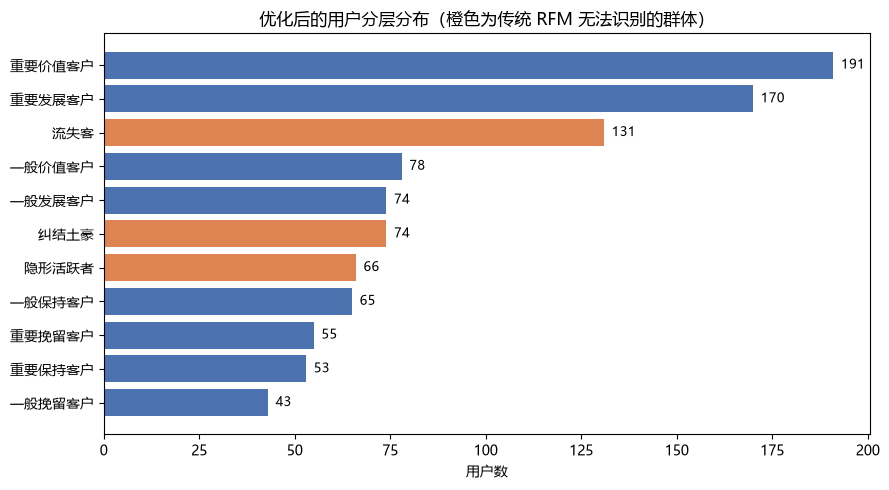

In [27]:
# ============ 第11步：可视化 ============
import matplotlib.pyplot as plt
import seaborn as sns

# 中文字体设置（关键！）
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# ---------- 图1：优化分层分布（横向柱状图） ----------
seg_counts = df["segment_optimized"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
# 三类新用户用橙色高亮，其余用蓝色
colors = ["#DD8452" if s in ["纠结土豪", "隐形活跃者", "流失客"] else "#4C72B0" for s in seg_counts.index]
ax.barh(seg_counts.index, seg_counts.values, color=colors)
ax.set_xlabel("用户数")
ax.set_title("优化后的用户分层分布（橙色为传统 RFM 无法识别的群体）")
for i, v in enumerate(seg_counts.values):
    ax.text(v + 2, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig_01_segments.png", dpi=120)
plt.show()

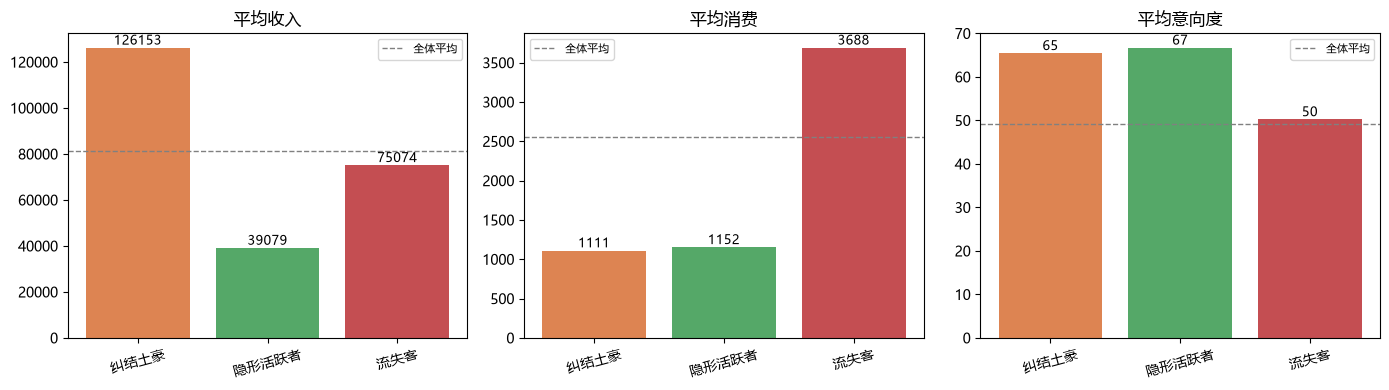

In [28]:
# ---------- 图2：三类新用户画像对比 ----------
new_segs = ["纠结土豪", "隐形活跃者", "流失客"]
profile = df[df["segment_optimized"].isin(new_segs)].groupby("segment_optimized").agg(
    平均收入=("Income", "mean"),
    平均消费=("Total_Spending", "mean"),
    平均意向度=("intention", "mean"),
).reindex(new_segs)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["平均收入", "平均消费", "平均意向度"]
colors3 = ["#DD8452", "#55A868", "#C44E52"]

for ax, metric in zip(axes, metrics):
    bars = ax.bar(profile.index, profile[metric], color=colors3)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=15)
    # 加全体平均线做对比
    col_map = {"平均收入": "Income", "平均消费": "Total_Spending", "平均意向度": "intention"}
    ax.axhline(df[col_map[metric]].mean(), color="gray", ls="--", lw=1, label="全体平均")
    ax.legend(fontsize=8)
    for b, v in zip(bars, profile[metric]):
        ax.text(b.get_x() + b.get_width()/2, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("fig_02_new_segments.png", dpi=120)
plt.show()

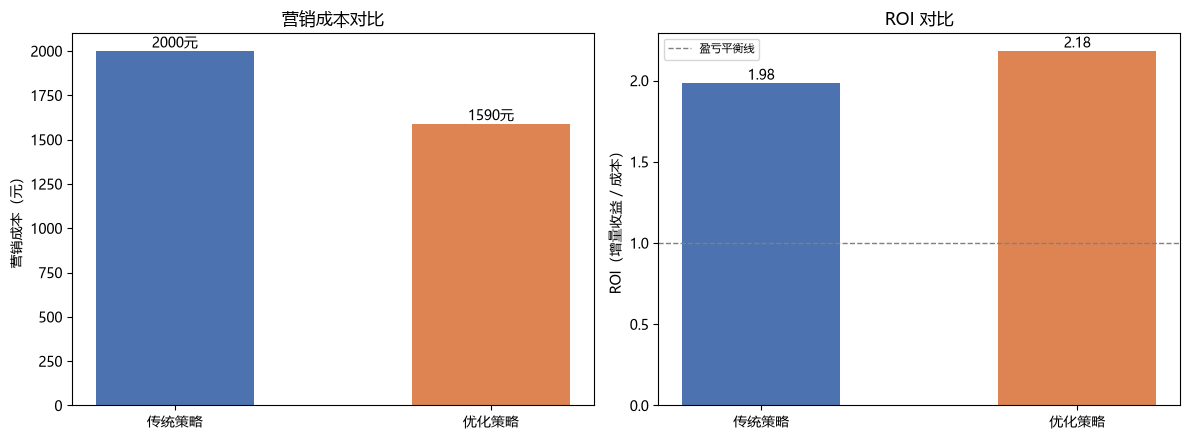

In [29]:
# ---------- 图3：A/B 增量效果对比 ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 左图：成本对比
strategies = ["传统策略", "优化策略"]
costs = [t_cost, o_cost]
bars = axes[0].bar(strategies, costs, color=["#4C72B0", "#DD8452"], width=0.5)
axes[0].set_ylabel("营销成本（元）")
axes[0].set_title("营销成本对比")
for b, v in zip(bars, costs):
    axes[0].text(b.get_x()+b.get_width()/2, v, f"{v:.0f}元", ha="center", va="bottom")

# 右图：ROI 对比
rois = [t_rev/t_cost, o_rev/o_cost]
bars2 = axes[1].bar(strategies, rois, color=["#4C72B0", "#DD8452"], width=0.5)
axes[1].set_ylabel("ROI（增量收益 / 成本）")
axes[1].set_title("ROI 对比")
axes[1].axhline(1.0, color="gray", ls="--", lw=1, label="盈亏平衡线")
axes[1].legend(fontsize=8)
for b, v in zip(bars2, rois):
    axes[1].text(b.get_x()+b.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("fig_03_ab_test.png", dpi=120)
plt.show()